In [7]:
# imports
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from dataset import BraTSDataset
from model import UNet
from dice_loss import DiceLoss
from dataset import get_dataloaders
from train import train_epoch, validate
import glob
from sklearn.model_selection import train_test_split

In [8]:
# set up hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 1e-4
print(f"Using device: {DEVICE}")

Using device: cuda


In [9]:
# initialize dataloaders
# TODO: Define file paths, instantiate BraTSDataset, and create PyTorch DataLoaders
all_files = glob.glob("data/**/*.h5", recursive=True)
print("Number of files:", len(all_files))
train_paths, val_paths = train_test_split(all_files, test_size=0.2, random_state=0)
train_loader, val_loader = get_dataloaders(train_paths, val_paths, batch_size=4)

# check dimensions
for images, masks in train_loader:
    print(images.shape)
    print(masks.shape)
    break

Number of files: 155
torch.Size([4, 4, 240, 240])
torch.Size([4, 3, 240, 240])


In [10]:
# initialize model, loss, and optimizer
model = UNet(in_channels=4, out_channels=3).to(DEVICE)
criterion = DiceLoss()
# use adam optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [11]:
# main training loop

train_losses = []
val_losses = []
val_dices =[]
best_val_dice = 0.0

print("Starting training...")
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    # 1. Train for one epoch (using the function from train.py)
    # Note: Make sure train_loader and val_loader are defined in Cell 3!
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    
    # 2. Validate for one epoch (using the function from train.py)
    val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)
    
    # 3. Save metrics for plotting later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    
    # 4. Save the best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_model.pth")
        print(">>> Best model saved!")

print("Training Complete!")

Starting training...

--- Epoch 1/100 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  5.97it/s]


Train Loss: 0.9798 | Val Loss: 0.9836 | Val Dice: 0.0164
>>> Best model saved!

--- Epoch 2/100 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  6.22it/s]


Train Loss: 0.9748 | Val Loss: 0.9808 | Val Dice: 0.0192
>>> Best model saved!

--- Epoch 3/100 ---


...

Train Loss: 0.0930 | Val Loss: 0.1700 | Val Dice: 0.8300

--- Epoch 99/100 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  6.36it/s]


Train Loss: 0.1386 | Val Loss: 0.1665 | Val Dice: 0.8335
>>> Best model saved!

--- Epoch 100/100 ---


Validating: 100%|██████████| 8/8 [00:01<00:00,  6.31it/s]

Train Loss: 0.1436 | Val Loss: 0.1690 | Val Dice: 0.8310
Training Complete!


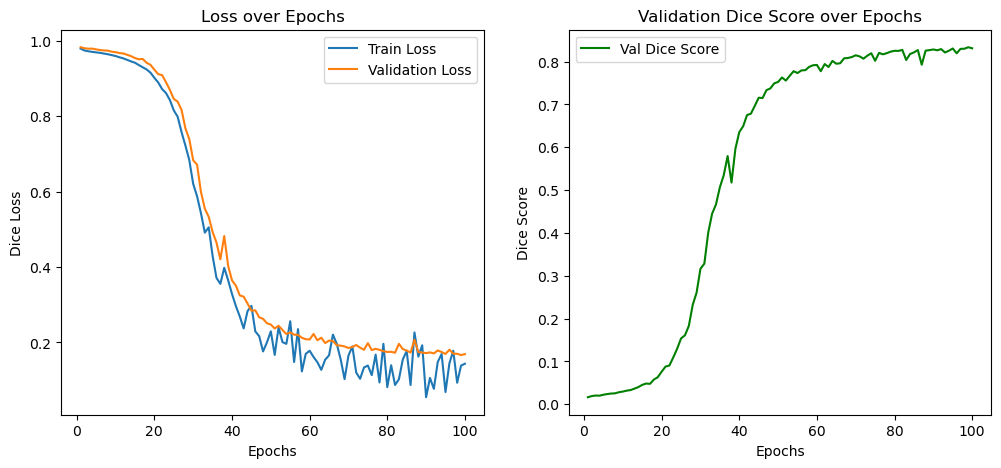

In [12]:
# plotting training graphs
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# plot losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.legend()

# plot dice score
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_dices, label='Val Dice Score', color='green')
plt.title('Validation Dice Score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.show()

Visualizing slice at batch index: 1


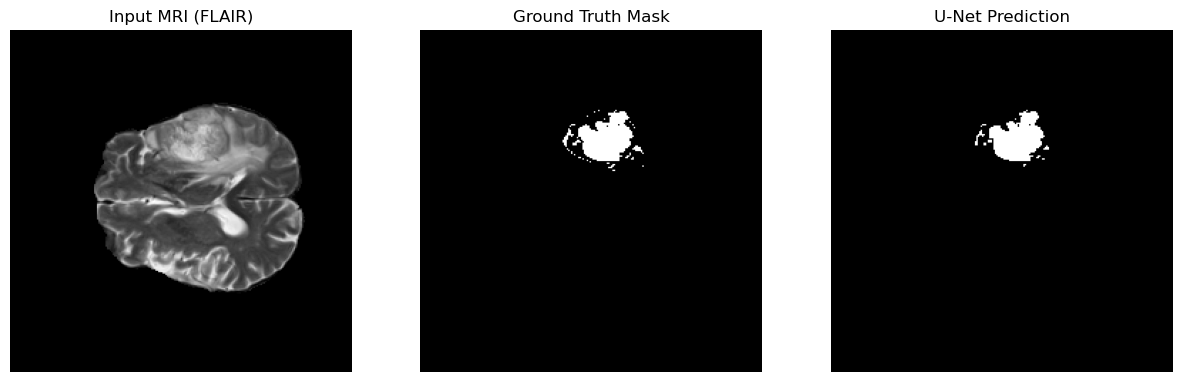

In [22]:
# visualize results

# Load the best weights
model.load_state_dict(torch.load("best_unet_model.pth"))
model.eval()

# Grab one batch of data from the validation set
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

# Get predictions
with torch.no_grad():
    predictions = model(images)
    probabilities = torch.sigmoid(predictions)
    predicted_masks = (probabilities > 0.5).float()

# find first slice with tumor
idx = 0 
for i in range(images.shape[0]):
    if masks[i].sum() > 100:
        idx = i            
        break              
    
# Move tensors back to CPU for matplotlib
image_cpu = images[idx].cpu().numpy() # Taking the first image in the batch
mask_cpu = masks[idx].cpu().numpy()
pred_cpu = predicted_masks[idx].cpu().numpy()

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Displaying the FLAIR channel 
flair_idx = 3 if image_cpu.shape[0] == 4 else 0
axs[0].imshow(image_cpu[flair_idx, :, :], cmap='gray') 
axs[0].set_title('Input MRI (FLAIR)')
axs[0].axis('off')

# Displaying Ground Truth 
axs[1].imshow(mask_cpu[0, :, :], cmap='gray') 
axs[1].set_title('Ground Truth Mask')
axs[1].axis('off')

# Displaying Prediction 
axs[2].imshow(pred_cpu[0, :, :], cmap='gray')
axs[2].set_title('U-Net Prediction')
axs[2].axis('off')

plt.show()